In [1]:
#!/usr/bin/env python3
import os, glob
import numpy as np
import libstempo as lt
from libstempo import toasim
import pickle
from pathlib import Path
from enterprise.pulsar import Pulsar


# ================================================================
# INPUT / OUTPUT DIRECTORIES
# ================================================================
par_dir   = "/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/par"
tim_dir   = "/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/tim"

clean_dir = "/scratch/na00078/projects/IPTA_MDC2/clean_noCW_libstempo_final"
reinj_dir = "/scratch/na00078/projects/IPTA_MDC2/reinj_correctedCW_libstempo_final"

pkl_dir   = Path("/scratch/na00078/projects/IPTA_MDC2/IPTA_MDC2_data/psr_objects")
pkl_dir.mkdir(parents=True, exist_ok=True)

os.makedirs(clean_dir, exist_ok=True)
os.makedirs(reinj_dir, exist_ok=True)


# ================================================================
# TRUE PARAMETERS (FROM MDC2)
# ================================================================
gwtheta = 0.6387905062299246
gwphi   = 3.3335788713091694
mc      = 4.3e9
dist    = 75.4           # Mpc
fgw     = 3.7e-9
phase0  = 0.24434609527920614
psi_old = 1.1187560505283651
psi_new = 1.1187560505283651   # <-- MODIFY when testing corrected ψ
inc     = 0.8412486994612669

# libstempo expects tref in *days*, not seconds.
tref_days = 55443.93364609394      # === CHANGE: convert to days (much safer)


# ================================================================
# UTIL FUNCTION TO CREATE A DEEP COPY OF STOAS
# ================================================================
def remove_cw(psr, **params):
    """
    Remove CW using libstempo injection function (the ONLY reliable method).
    """
    # Backup original TOAs
    orig_stoas = psr.stoas.copy()

    # Inject original CW
    toasim.add_cgw(psr, **params)

    # Now psr.stoas contains (TOA + CW_injection)
    injected = psr.stoas.copy()

    # Remove it → restored "clean"
    psr.stoas[:] = orig_stoas - (injected - orig_stoas)

    return


# ================================================================
# STEP 1 — REMOVE ORIGINAL CW (via libstempo add_cgw)
# ================================================================
print("\n=== Removing original CW using libstempo.toasim.add_cgw ===")

inject_kwargs_old = dict(
    gwtheta = gwtheta,
    gwphi   = gwphi,
    mc      = mc,
    dist    = dist,
    fgw     = fgw,
    phase0  = phase0,
    psi     = psi_old,
    inc     = inc,
    tref    = tref_days,
    psrTerm = True,
    evolve  = True,
)

pars = sorted(glob.glob(os.path.join(par_dir, "*.par")))
for p in pars:
    name = os.path.basename(p)[:-4]
    tpath = os.path.join(tim_dir, f"{name}.tim")
    psr = lt.tempopulsar(p, tpath)

    # === CLEANING ===
    remove_cw(psr, **inject_kwargs_old)

    # Save cleaned dataset
    psr.savetim(os.path.join(clean_dir, f"{name}.tim"))
    os.system(f"cp {p} {os.path.join(clean_dir, name+'.par')}")

print("Done cleaning.")


# ================================================================
# STEP 2 — REINJECT CORRECTED ψ USING libstempo.toasim.add_cgw
# ================================================================
print("\n=== Reinjection with NEW psi using libstempo.toasim.add_cgw ===")

inject_kwargs_new = inject_kwargs_old.copy()
inject_kwargs_new["psi"] = psi_new

clean_pars = sorted(glob.glob(os.path.join(clean_dir, "*.par")))
for p in clean_pars:
    name = os.path.basename(p)[:-4]
    tpath = os.path.join(clean_dir, f"{name}.tim")
    psr = lt.tempopulsar(p, tpath)

    # === REINJECT CORRECTED ψ ===
    toasim.add_cgw(psr, **inject_kwargs_new)

    psr.savetim(os.path.join(reinj_dir, f"{name}.tim"))
    os.system(f"cp {p} {os.path.join(reinj_dir, name+'.par')}")

print("Reinjection complete.")


# ================================================================
# STEP 3 — BUILD PKL FILE OF FINAL (REINJECTED) PULSAR OBJECTS
# ================================================================
print("\n=== Creating PKL file of reinjected pulsars ===")

reinj_pars = sorted(Path(reinj_dir).glob("*.par"))
pulsars = []
skipped = []

for par in reinj_pars:
    tim = Path(reinj_dir) / (par.stem + ".tim")
    try:
        psr = Pulsar(str(par), str(tim), timing_package="tempo2")
        pulsars.append(psr)
    except Exception as e:
        skipped.append((par.name, str(e)))

pkl_out = pkl_dir / "G2D2_new_one_source_sim_final.pkl"
with open(pkl_out, "wb") as f:
    pickle.dump(pulsars, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved {len(pulsars)} pulsars to {pkl_out}")
if skipped:
    print("Skipped:")
    for name, reason in skipped:
        print(f"  {name}: {reason}")

print("\n=== ALL DONE ===")



=== Removing original CW using libstempo.toasim.add_cgw ===
Done cleaning.

=== Reinjection with NEW psi using libstempo.toasim.add_cgw ===
Reinjection complete.

=== Creating PKL file of reinjected pulsars ===


Saved 33 pulsars to /scratch/na00078/projects/IPTA_MDC2/IPTA_MDC2_data/psr_objects/G2D2_new_one_source_sim_final.pkl

=== ALL DONE ===


# ---------------------------------------------------------
# VERIFICATION: Check whether subtraction & reinjection worked
# ---------------------------------------------------------


              SANITY CHECK RESULTS



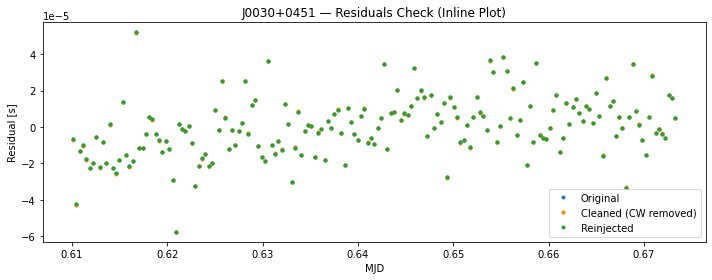

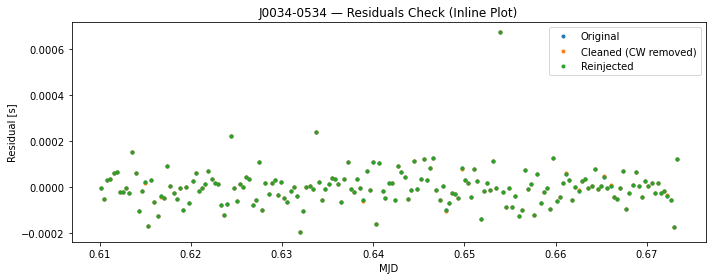

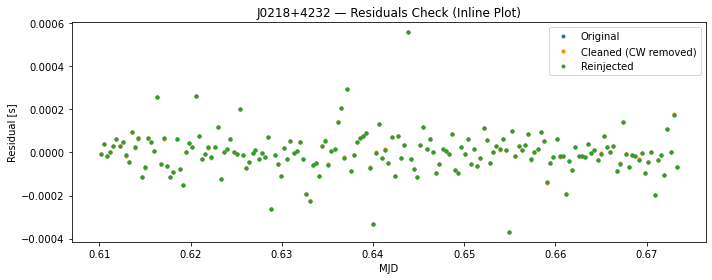

PULSAR           RMS_orig      RMS_clean     RMS_reinj    RMS(orig-clean)  RMS(reinj-clean)
-------------------------------------------------------------------------------------------------
J0030+0451     1.608e-05   1.609e-05   1.608e-05     1.584e-07        1.584e-07
J0034-0534     8.309e-05   8.308e-05   8.309e-05     2.757e-07        2.757e-07
J0218+4232     9.687e-05   9.685e-05   9.687e-05     5.971e-07        5.971e-07
J0437-4715     1.122e-06   1.120e-06   1.122e-06     7.540e-08        7.540e-08
J0613-0200     2.654e-05   2.650e-05   2.654e-05     4.151e-07        4.151e-07
J0621+1002     1.082e-04   1.080e-04   1.082e-04     9.091e-07        9.091e-07
J0711-6830     2.445e-05   2.445e-05   2.445e-05     9.662e-08        9.662e-08
J0751+1807     2.940e-05   2.941e-05   2.940e-05     6.120e-07        6.120e-07
J0900-3144     3.520e-05   3.532e-05   3.520e-05     6.737e-07        6.737e-07
J1012+5307     3.810e-05   3.814e-05   3.810e-05     1.461e-06        1.461e-06
J1022+1001

In [2]:
# ================================================================
# SANITY CHECK: Validate CW removal and reinjection
# ================================================================
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import libstempo as lt
import glob
import os

# -------------------------------
# DIRECTORIES (your exact paths)
# -------------------------------
par_dir   = "/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/par"
tim_dir   = "/scratch/na00078/projects/IPTA_MDC2/mdc2/group2/dataset_2/tim"

clean_dir = "/scratch/na00078/projects/IPTA_MDC2/clean_noCW_libstempo_final"
reinj_dir = "/scratch/na00078/projects/IPTA_MDC2/reinj_correctedCW_libstempo_final"

pkl_dir   = Path("/scratch/na00078/projects/IPTA_MDC2/IPTA_MDC2_data/psr_objects")
pkl_dir.mkdir(parents=True, exist_ok=True)


# -------------------------------
# Helper function
# -------------------------------
def rms(x):
    return np.sqrt(np.mean(x**2))


print("\n====================================================")
print("              SANITY CHECK RESULTS")
print("====================================================\n")


clean_files = sorted(Path(clean_dir).glob("*.par"))

example_plots = 3       # number of pulsars to SHOW inline
verify_stats = []       # collect stats


# ================================================================
# LOOP OVER PULSARS
# ================================================================
for i, p in enumerate(clean_files):
    name = p.stem

    # -----------------------------
    # Load original dataset
    # -----------------------------
    par0 = Path(par_dir) / f"{name}.par"
    tim0 = Path(tim_dir) / f"{name}.tim"
    psr0 = lt.tempopulsar(str(par0), str(tim0))
    r0   = psr0.residuals().copy()

    # -----------------------------
    # Load CLEAN dataset (CW removed)
    # -----------------------------
    par1 = Path(clean_dir) / f"{name}.par"
    tim1 = Path(clean_dir) / f"{name}.tim"
    psr1 = lt.tempopulsar(str(par1), str(tim1))
    r1   = psr1.residuals().copy()

    # -----------------------------
    # Load REINJECTED dataset
    # -----------------------------
    par2 = Path(reinj_dir) / f"{name}.par"
    tim2 = Path(reinj_dir) / f"{name}.tim"
    psr2 = lt.tempopulsar(str(par2), str(tim2))
    r2   = psr2.residuals().copy()

    # =============================
    # Compute RMS values
    # =============================
    rms0 = rms(r0)               # original
    rms1 = rms(r1)               # after CW removal
    rms2 = rms(r2)               # after reinjection

    diff_remove = r0 - r1        # difference = original CW contribution
    diff_reinj  = r2 - r1        # difference = reinjected CW

    rms_remove = rms(diff_remove)
    rms_reinj  = rms(diff_reinj)

    verify_stats.append([name, rms0, rms1, rms2, rms_remove, rms_reinj])

    # -------------------------------------------------------
    # INLINE PLOTS FOR FIRST FEW PULSARS (NO FILE SAVING)
    # -------------------------------------------------------
    if i < example_plots:
        plt.figure(figsize=(10, 4))
        plt.title(f"{name} — Residuals Check (Inline Plot)")
        mjd = psr0.toas() / 86400.0  # convert seconds → MJD

        plt.plot(mjd, r0, "o", label="Original", ms=3)
        plt.plot(mjd, r1, "o", label="Cleaned (CW removed)", ms=3)
        plt.plot(mjd, r2, "o", label="Reinjected", ms=3)
        plt.xlabel("MJD")
        plt.ylabel("Residual [s]")
        plt.legend()
        plt.tight_layout()
        plt.show()


# ================================================================
# PRINT SUMMARY TABLE
# ================================================================
print("PULSAR           RMS_orig      RMS_clean     RMS_reinj    RMS(orig-clean)  RMS(reinj-clean)")
print("-------------------------------------------------------------------------------------------------")

for name, rms0, rms1, rms2, rms_rm, rms_rj in verify_stats:
    print(f"{name:12s}  {rms0:10.3e}  {rms1:10.3e}  {rms2:10.3e}    {rms_rm:10.3e}       {rms_rj:10.3e}")

print("\n====================================================")
print("               SANITY CHECK COMPLETE")
print("====================================================\n")
